XGBOOST

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
CSV_INPUT_PATH = "audio_dataset.csv"
LABEL_COLUMN="portata"
MAX_N_ESTIMATORS=1000

In [3]:
# 1. CARICAMENTO DATI
# Assumiamo che il file CSV abbia la colonna identificativa come prima colonna
df = pd.read_csv(CSV_INPUT_PATH, index_col=0)

In [4]:
# 2. PREPARAZIONE X e y
target_column = 'portata'
X = df.drop(columns=[target_column])
y = df[target_column]

# 3. SPLIT TRAIN/TEST
# Dividiamo i dati: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 1. Split per la validazione (usiamo i dati di train per trovare il numero di alberi)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 2. Definiamo il modello con early_stopping_rounds dentro le parentesi
xgb_reg = xgb.XGBRegressor(
    n_estimators=MAX_N_ESTIMATORS, 
    learning_rate=0.1,
    early_stopping_rounds=10, # Si mette qui nelle nuove versioni
    random_state=42
)

# 3. Fit (l'eval_set è obbligatorio per l'early stopping)
xgb_reg.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)], 
    verbose=False
)

print(f"Numero ideale di alberi: {xgb_reg.best_iteration}")

Numero ideale di alberi: 89


In [6]:
# 1. PREPARAZIONE DATI (DMatrix è il formato ottimizzato per XGBoost)
# XGBoost funziona direttamente con X_train e y_train di scikit-learn
xgb_regressor = xgb.XGBRegressor(
    n_estimators=xgb_reg.best_iteration,    # 50 decisione tree
    learning_rate=0.1,   # "Passo" di apprendimento (fondamentale in XGB)
    max_depth=6,         # Profondità degli alberi
    subsample=0.8,       # Usa l'80% dei dati per ogni albero (evita overfitting)
    colsample_bytree=0.8, # Usa l'80% delle feature per ogni albero
    random_state=42,
    n_jobs=-1
)

# 2. TRAINING
xgb_regressor.fit(X_train, y_train)
print("Training completato.")

Training completato.


In [7]:
# 3. PREDIZIONE E VALUTAZIONE
y_pred_xgb = xgb_regressor.predict(X_test)

In [8]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"--- PERFORMANCE XGBOOST ---")
print(f"R^2 Score: {r2_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"RMSE: {rmse:.4f}")

--- PERFORMANCE XGBOOST ---
R^2 Score: 0.8302
MAE: 41.8410
RMSE: 61.5212


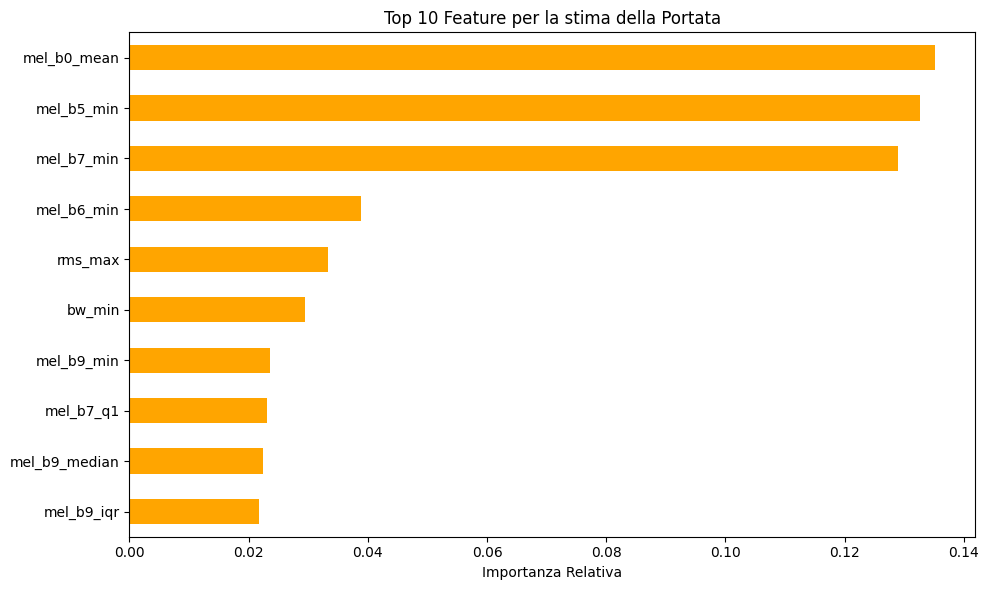

In [9]:
# VISUALIZZAZIONE: FEATURE IMPORTANCE
plt.figure(figsize=(10, 6))
importances = pd.Series(xgb_regressor.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='orange')
plt.title("Top 10 Feature per la stima della Portata")
plt.xlabel("Importanza Relativa")
plt.tight_layout()
plt.show()